# Two-components Phase Exploration Visualizations

This notebook focuses on `two_components/outputs/phase_exploration/exploration_ensemble.csv`.
It compares the best (`min J_m`) and worst (`max J_m`) exploration runs against observed data.

## 1) Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
## 2) Import model setup and load data

In [3]:
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root))

from reactive_transport.simulation_options_2 import simulateDualPorosity


def load_data(csv_path):
    df = pd.read_csv(csv_path)
    weights = df["weight"].to_numpy()
    mask = weights.astype(bool)
    t_true = df["Time_hr"].to_numpy()[mask]
    c_true = df["C_corr_mgL"].to_numpy()[mask]
    return t_true, c_true


def modelRELAP(t, mrt, pec):
    frac_retard = 1.0
    bckgrnd_conc = 0.0
    inj_concs = np.array([7.0, 0.0], dtype=float)
    inj_durs = np.cumsum(np.array([1.5], dtype=float))
    dpParam = 0
    matrix_retardation = 1.0
    recRatio = 0.0
    wsCoef = 0.0
    return simulateDualPorosity(
        mrt,
        pec,
        frac_retard,
        t,
        bckgrnd_conc,
        inj_concs,
        inj_durs,
        dpParam,
        matrix_retardation,
        recRatio=recRatio,
        wsCoef=wsCoef,
        delay_time=0,
    )


def modelRELAP2(t, mrt1, mrt2, pec1, pec2, fr1, fr2):
    c1 = modelRELAP(t, mrt1, pec1)
    c2 = modelRELAP(t, mrt2, pec2)
    return fr1 * c1 + fr2 * c2


exploration_csv = repo_root / "two_components/outputs/phase_exploration/exploration_ensemble.csv"
exploration_csv = "../exploration_ensemble.csv"
ensemble = pd.read_csv(exploration_csv)
t_true, c_true = load_data(str(repo_root / "data/data.csv"))

best_row = ensemble.loc[ensemble["J_m"].idxmin()]
worst_row = ensemble.loc[ensemble["J_m"].idxmax()]

## 3) Run best-case simulation (parameters + model execution)

In [4]:
best_params = (
    best_row["best_MRT1"],
    best_row["best_MRT2"],
    best_row["best_Pe1"],
    best_row["best_Pe2"],
    best_row["best_fr1"],
    best_row["best_fr2"],
)

c_best = modelRELAP2(t_true, *best_params)

## 4) Run worst-case simulation (parameters + model execution)

In [5]:
worst_params = (
    worst_row["best_MRT1"],
    worst_row["best_MRT2"],
    worst_row["best_Pe1"],
    worst_row["best_Pe2"],
    worst_row["best_fr1"],
    worst_row["best_fr2"],
)

c_worst = modelRELAP2(t_true, *worst_params)

## 5) Visualizations

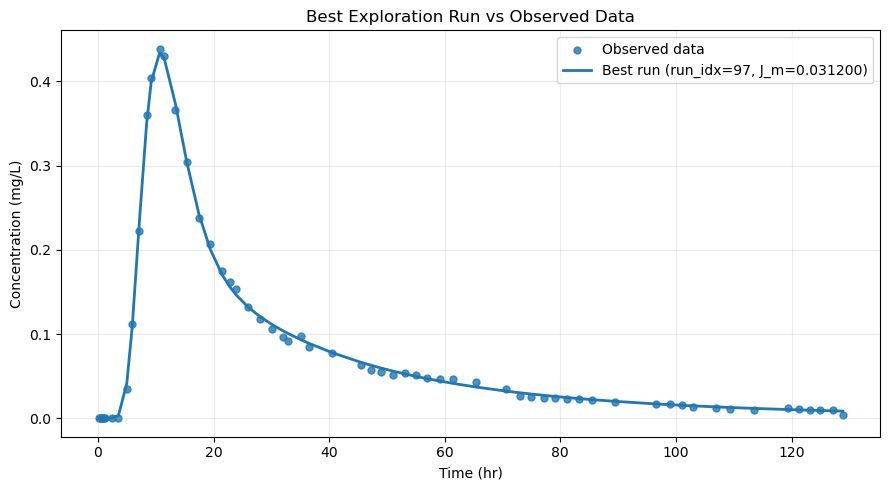

In [6]:
plt.figure(figsize=(9, 5))
plt.scatter(t_true, c_true, s=25, alpha=0.8, label="Observed data")
plt.plot(
    t_true,
    c_best,
    linewidth=2.0,
    label=f"Best run (run_idx={int(best_row['run_idx'])}, J_m={best_row['J_m']:.6f})",
)
plt.xlabel("Time (hr)")
plt.ylabel("Concentration (mg/L)")
plt.title("Best Exploration Run vs Observed Data")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

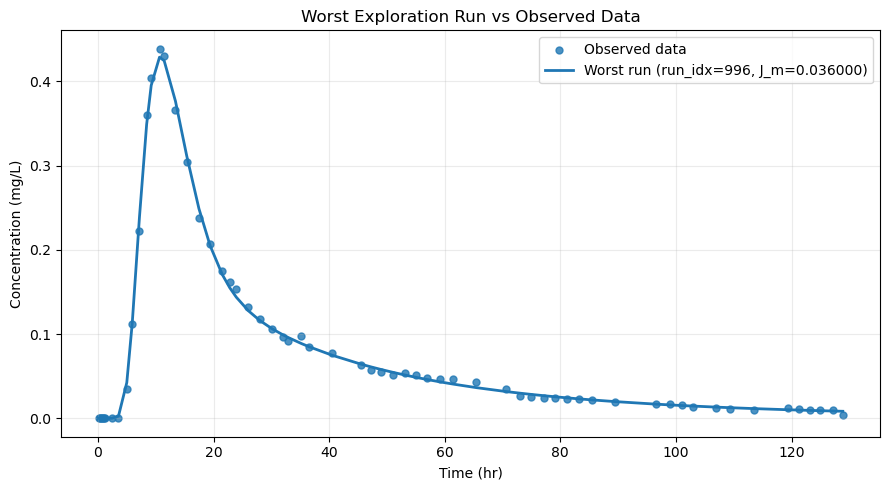

In [7]:
plt.figure(figsize=(9, 5))
plt.scatter(t_true, c_true, s=25, alpha=0.8, label="Observed data")
plt.plot(
    t_true,
    c_worst,
    linewidth=2.0,
    label=f"Worst run (run_idx={int(worst_row['run_idx'])}, J_m={worst_row['J_m']:.6f})",
)
plt.xlabel("Time (hr)")
plt.ylabel("Concentration (mg/L)")
plt.title("Worst Exploration Run vs Observed Data")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6) Parameter histograms colored by median J_m

Each histogram bar shows run count, and its color is based on the median `J_m` of samples inside that bin.

In [8]:
import matplotlib as mpl

cmap = plt.cm.jet
j_norm = mpl.colors.Normalize(vmin=ensemble["J_m"].min(), vmax=ensemble["J_m"].max())

def plot_hist_colored_by_jm(df, column, bins=30):
    values = df[column].to_numpy()
    j_vals = df["J_m"].to_numpy()

    counts, edges = np.histogram(values, bins=bins)
    bin_ids = np.digitize(values, edges) - 1
    bin_ids = np.clip(bin_ids, 0, len(edges) - 2)

    bin_medians = np.full(len(edges) - 1, np.nan)
    for i in range(len(bin_medians)):
        mask = bin_ids == i
        if np.any(mask):
            bin_medians[i] = np.median(j_vals[mask])

    colors = [cmap(j_norm(v)) if not np.isnan(v) else (0.85, 0.85, 0.85, 1.0) for v in bin_medians]

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.bar(edges[:-1], counts, width=np.diff(edges), align="edge", color=colors, edgecolor="black", linewidth=0.4)
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    ax.set_title(f"{column} distribution (bar color = median J_m)")
    ax.grid(alpha=0.2)

    sm = mpl.cm.ScalarMappable(norm=j_norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("J_m")

    plt.tight_layout()
    plt.show()

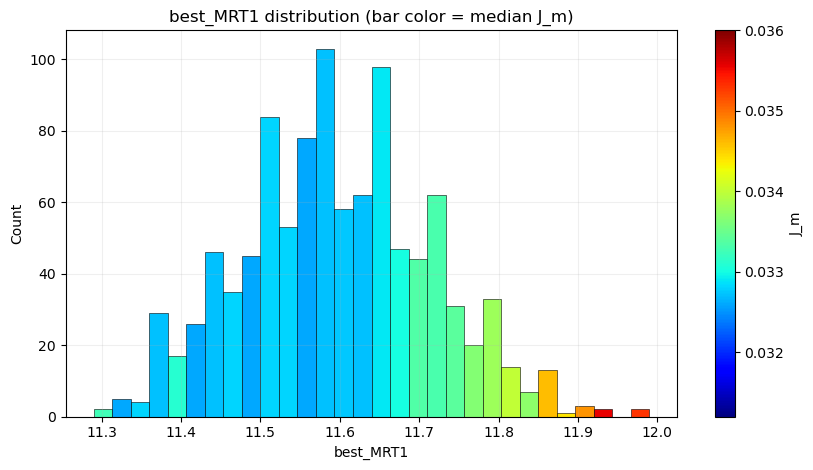

In [9]:
plot_hist_colored_by_jm(ensemble, "best_MRT1")

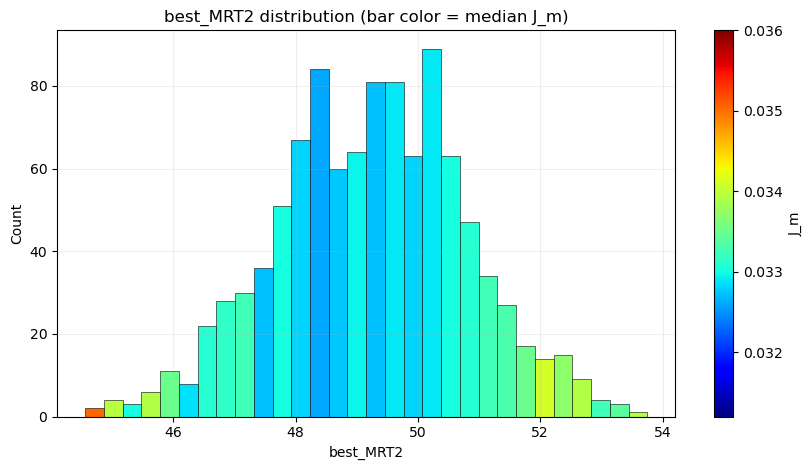

In [10]:
plot_hist_colored_by_jm(ensemble, "best_MRT2")

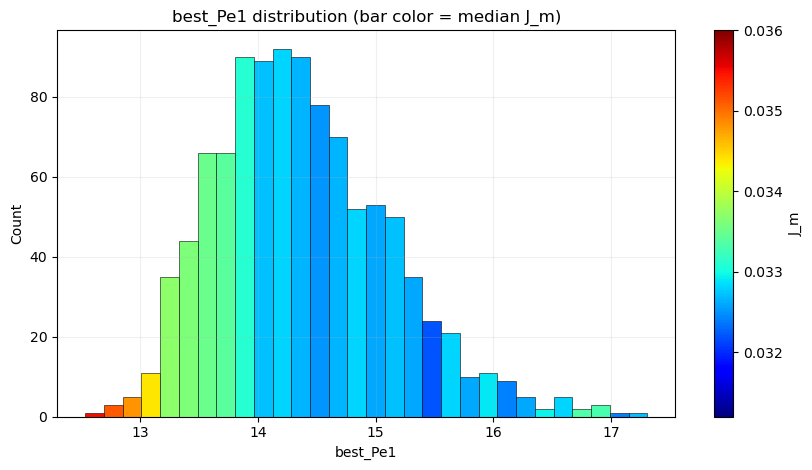

In [11]:
plot_hist_colored_by_jm(ensemble, "best_Pe1")

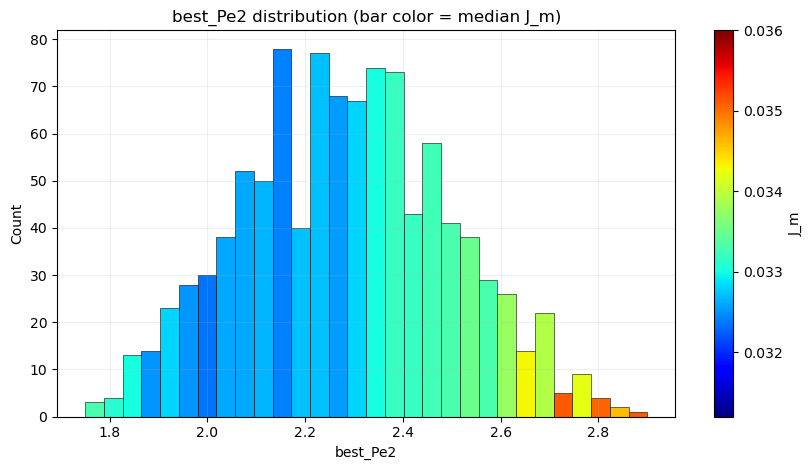

In [12]:
plot_hist_colored_by_jm(ensemble, "best_Pe2")

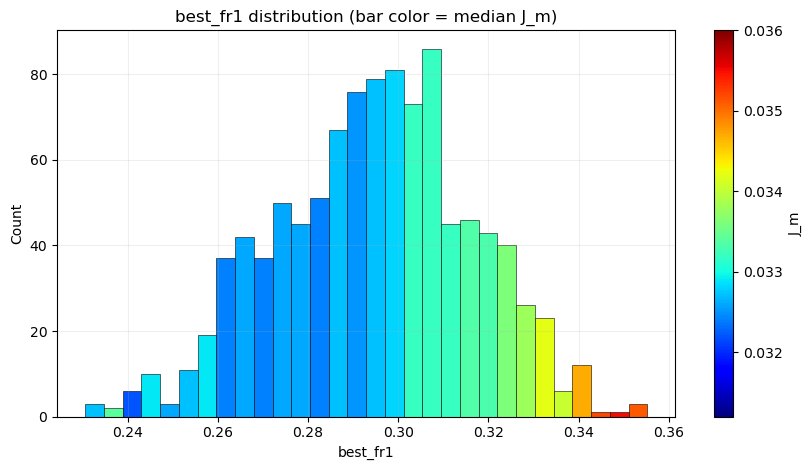

In [13]:
plot_hist_colored_by_jm(ensemble, "best_fr1")

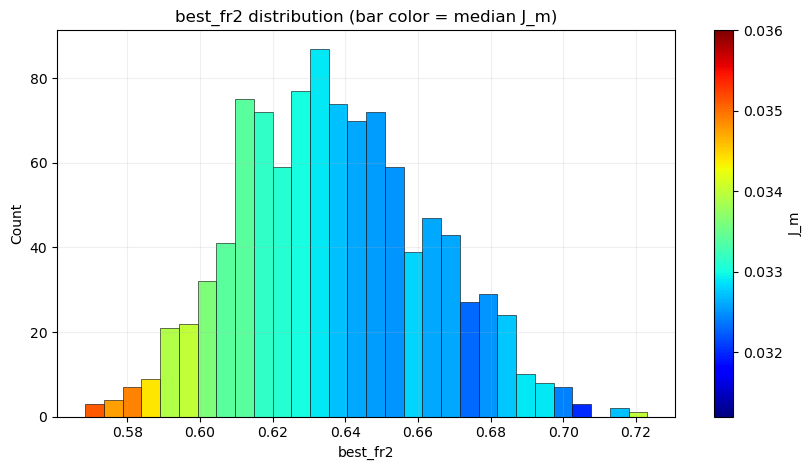

In [14]:
plot_hist_colored_by_jm(ensemble, "best_fr2")

## 7) Objective value `J_m` distribution

Histogram of `J_m` across all exploration runs (overall quality spread).

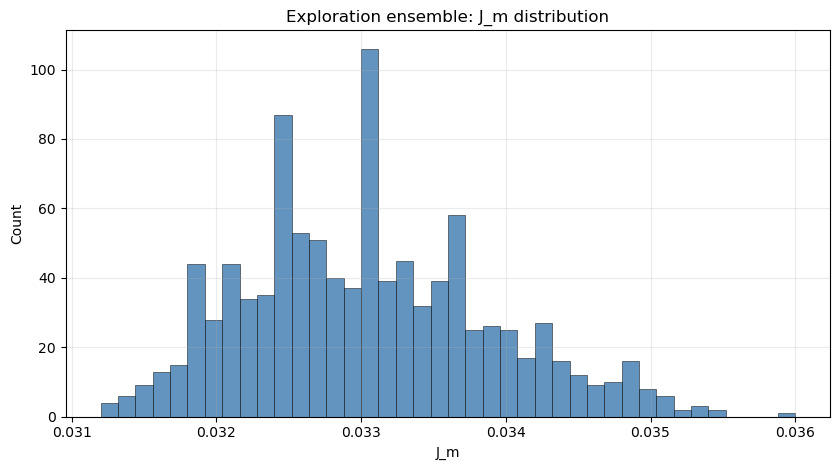

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.hist(ensemble["J_m"], bins=40, color="steelblue", edgecolor="black", linewidth=0.4, alpha=0.85)
ax.set_xlabel("J_m")
ax.set_ylabel("Count")
ax.set_title("Exploration ensemble: J_m distribution")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8) Boxplots for each fitted parameter

Compact view of median, quartiles, and outliers for each parameter (same scale within each panel only).

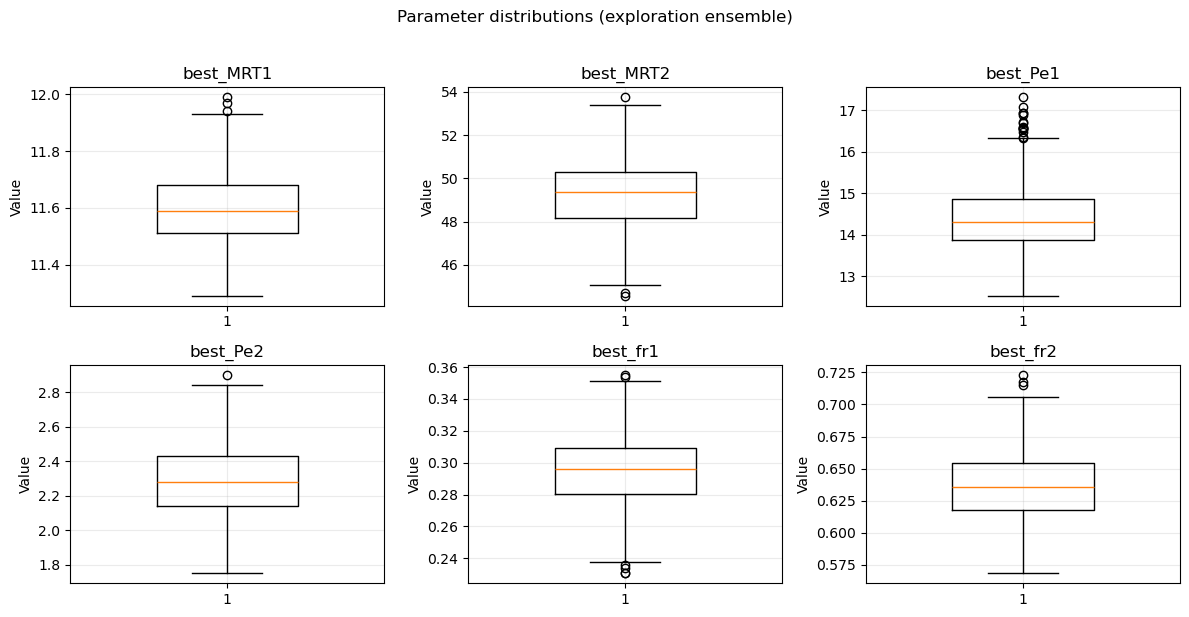

In [16]:
param_cols = ["best_MRT1", "best_MRT2", "best_Pe1", "best_Pe2", "best_fr1", "best_fr2"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.flatten(), param_cols):
    ax.boxplot(ensemble[col].to_numpy(), vert=True, widths=0.45)
    ax.set_title(col)
    ax.set_ylabel("Value")
    ax.grid(alpha=0.25)
plt.suptitle("Parameter distributions (exploration ensemble)", y=1.02)
plt.tight_layout()
plt.show()

## 9) Spearman correlation matrix

Monotonic associations between parameters and `J_m` (robust to skewed marginals).

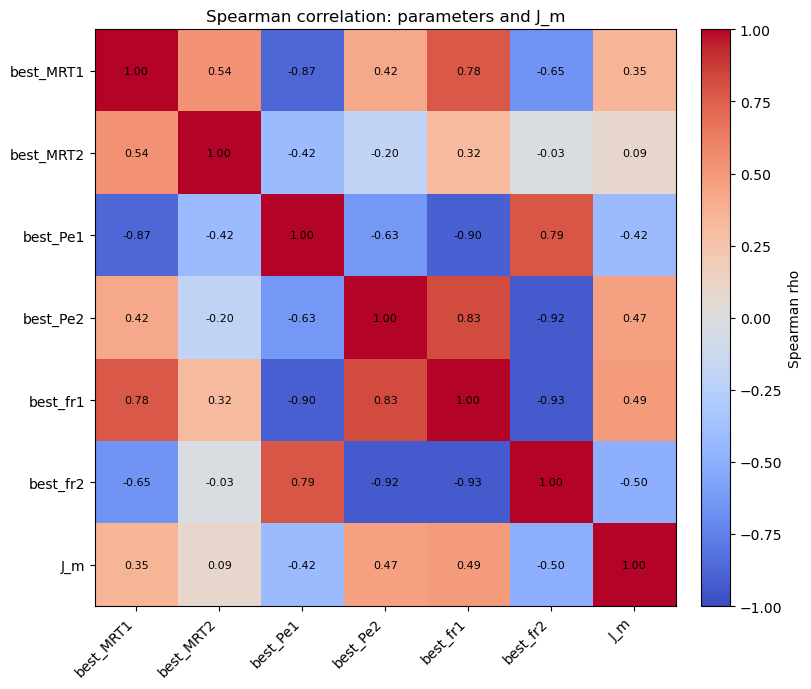

In [17]:
param_cols = ["best_MRT1", "best_MRT2", "best_Pe1", "best_Pe2", "best_fr1", "best_fr2"]
corr_cols = param_cols + ["J_m"]
corr = ensemble[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.2, 7))
im = ax.imshow(corr.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman rho")
ax.set_title("Spearman correlation: parameters and J_m")
plt.tight_layout()
plt.show()

## 10) Each parameter vs `J_m` (scatter)

Shows where in parameter space the better (lower) `J_m` values tend to occur. Points use modest alpha for overlap.

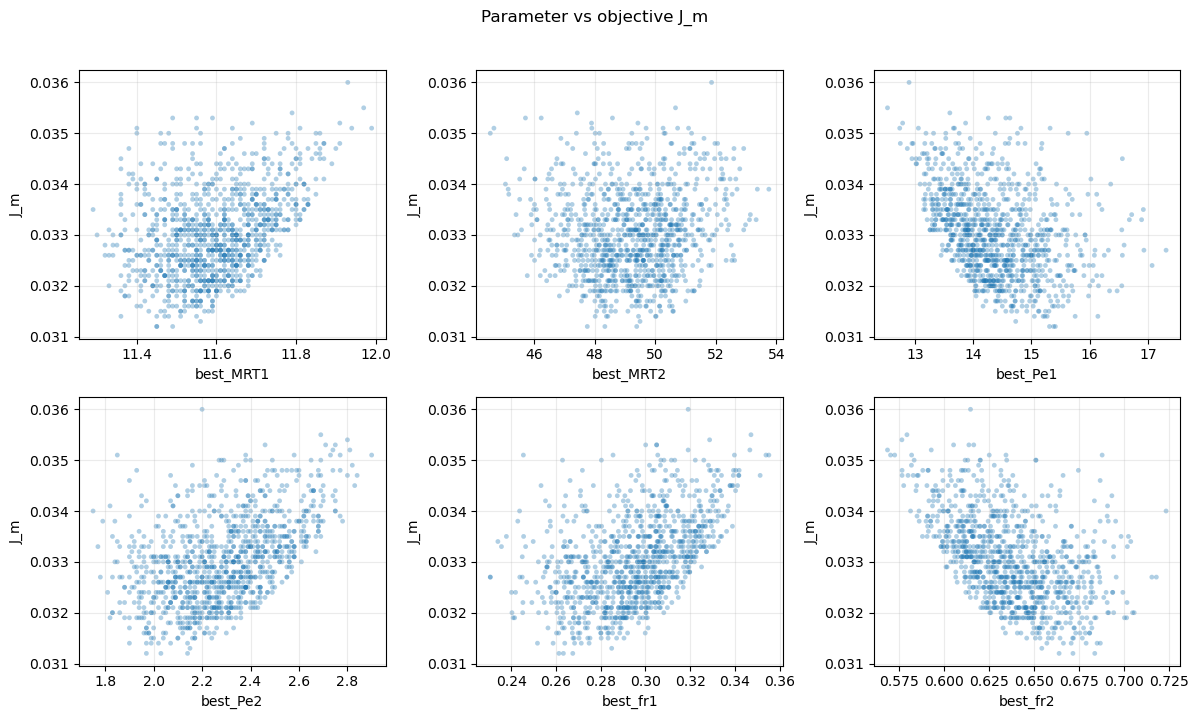

In [18]:
param_cols = ["best_MRT1", "best_MRT2", "best_Pe1", "best_Pe2", "best_fr1", "best_fr2"]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.flatten(), param_cols):
    ax.scatter(ensemble[col], ensemble["J_m"], s=12, alpha=0.35, edgecolors="none")
    ax.set_xlabel(col)
    ax.set_ylabel("J_m")
    ax.grid(alpha=0.25)
plt.suptitle("Parameter vs objective J_m", y=1.02)
plt.tight_layout()
plt.show()

## 11) Pairwise parameter planes colored by `J_m`

Natural pairs: MRT1 vs MRT2, Pe1 vs Pe2, fr1 vs fr2. Color shows `J_m` on the same global scale as the histogram section.

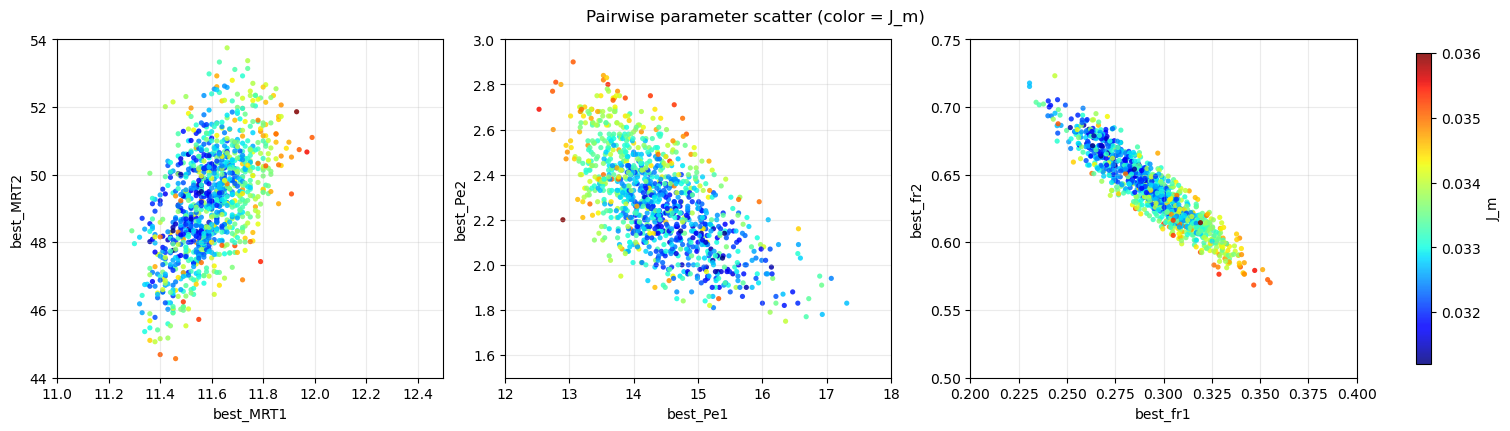

In [19]:
import matplotlib as mpl

param_cols = ["best_MRT1", "best_MRT2", "best_Pe1", "best_Pe2", "best_fr1", "best_fr2"]
j_norm_pair = mpl.colors.Normalize(vmin=ensemble["J_m"].min(), vmax=ensemble["J_m"].max())

pairs = [
    ("best_MRT1", "best_MRT2"),
    ("best_Pe1", "best_Pe2"),
    ("best_fr1", "best_fr2"),
]
axis_limits = [
    ([11, 12.5], [44, 54]),
    ([12, 18], [1.5, 3]),
    ([0.2, 0.4], [0.5, 0.75]),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
sc = None
for ax, (cx, cy), (xlim, ylim) in zip(axes, pairs, axis_limits):
    sc = ax.scatter(
        ensemble[cx],
        ensemble[cy],
        c=ensemble["J_m"],
        cmap="jet",
        norm=j_norm_pair,
        s=14,
        alpha=0.85,
        edgecolors="none",
    )
    ax.set_xlabel(cx)
    ax.set_ylabel(cy)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(alpha=0.25)
fig.colorbar(sc, ax=axes, shrink=0.92, pad=0.03, label="J_m")
fig.suptitle("Pairwise parameter scatter (color = J_m)")
plt.show()

## 12) Empirical CDF of `J_m`

Cumulative distribution of objective values (easy to read percentiles from the curve).

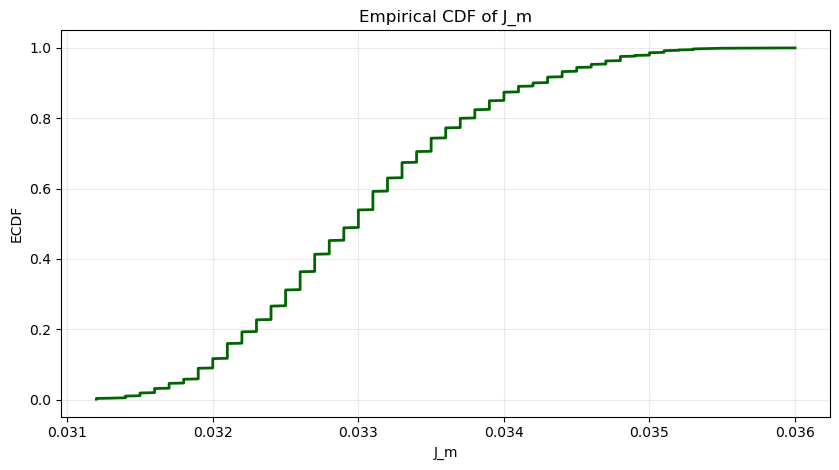

In [20]:
jm_sorted = np.sort(ensemble["J_m"].to_numpy())
n = len(jm_sorted)
cdf = (np.arange(1, n + 1)) / n

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(jm_sorted, cdf, color="darkgreen", linewidth=2)
ax.set_xlabel("J_m")
ax.set_ylabel("ECDF")
ax.set_title("Empirical CDF of J_m")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 13) 2D density: `best_MRT1` vs `best_MRT2` (hexbin)

Shows where runs concentrate in MRT space; counts per hex cell.

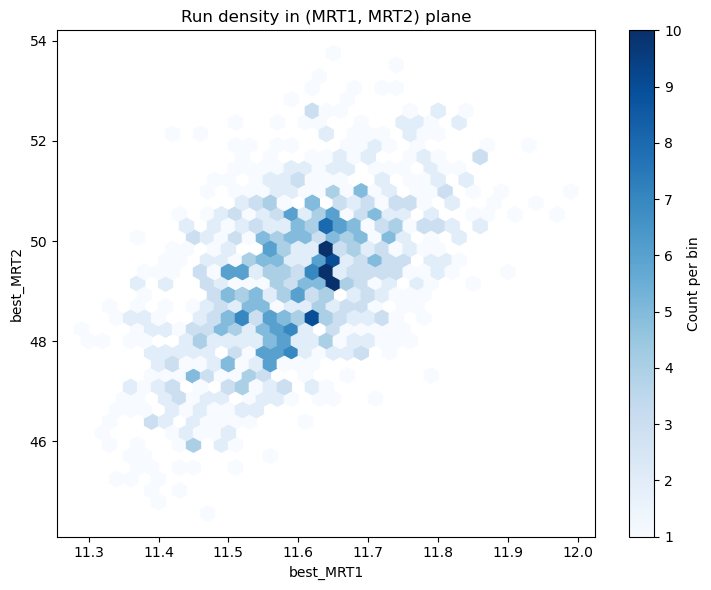

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 6))
hb = ax.hexbin(
    ensemble["best_MRT1"],
    ensemble["best_MRT2"],
    gridsize=35,
    mincnt=1,
    cmap="Blues",
)
ax.set_xlabel("best_MRT1")
ax.set_ylabel("best_MRT2")
ax.set_title("Run density in (MRT1, MRT2) plane")
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Count per bin")
plt.tight_layout()
plt.show()

## 14) `run_idx` vs `J_m`

Quick check of whether later runs systematically differ (e.g. ordering effects) or scatter randomly.

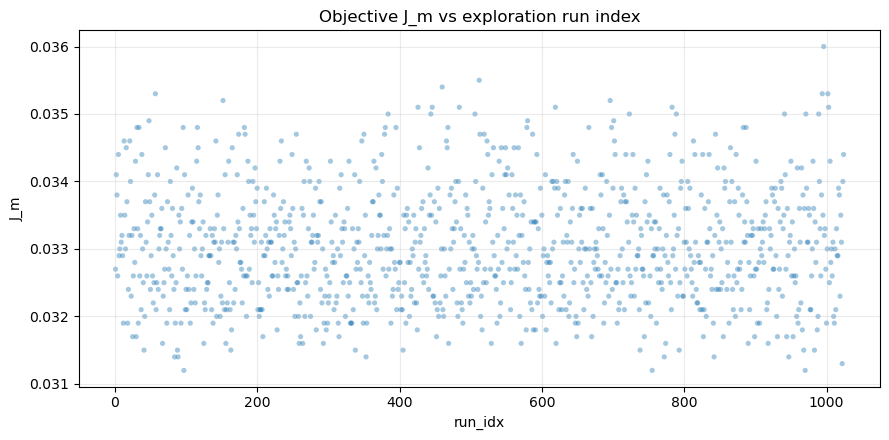

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(ensemble["run_idx"], ensemble["J_m"], s=14, alpha=0.4, edgecolors="none")
ax.set_xlabel("run_idx")
ax.set_ylabel("J_m")
ax.set_title("Objective J_m vs exploration run index")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 15) Observed data vs best-fit model curves (mean + 95% band)

Uses the **top N exploration runs** (lowest `J_m`). For each run, the forward model gives a full curve `C(t)`. Stacking those curves gives a **mean prediction** and **2.5–97.5%** percentile band (shown like a GPR mean with uncertainty). This is uncertainty **across comparable good fits**, not a GP fit to the observations.

In [ ]:
N_best = 1024
elite = ensemble.nsmallest(N_best, "J_m")

t_plot = np.linspace(0.01, 130, 250)

curves_mix = []
curves_c1 = []
curves_c2 = []
for _, row in elite.iterrows():
    mrt1 = row["best_MRT1"]
    mrt2 = row["best_MRT2"]
    pec1 = row["best_Pe1"]
    pec2 = row["best_Pe2"]
    fr1 = row["best_fr1"]
    fr2 = row["best_fr2"]
    c1 = np.asarray(modelRELAP(t_plot, mrt1, pec1), dtype=float)
    c2 = np.asarray(modelRELAP(t_plot, mrt2, pec2), dtype=float)
    curves_c1.append(fr1 * c1)
    curves_c2.append(fr2 * c2)
    curves_mix.append(fr1 * c1 + fr2 * c2)

curves_mix = np.vstack(curves_mix)
curves_c1 = np.vstack(curves_c1)
curves_c2 = np.vstack(curves_c2)




In [39]:
def band_stats(curves_arr):
    mean_y = np.mean(curves_arr, axis=0)
    lo_y = np.percentile(curves_arr, 2.5, axis=0)
    hi_y = np.percentile(curves_arr, 97.5, axis=0)
    return mean_y, lo_y, hi_y


mean_mix, lo_mix, hi_mix = band_stats(curves_mix)
mean_1, lo_1, hi_1 = band_stats(curves_c1)
mean_2, lo_2, hi_2 = band_stats(curves_c2)

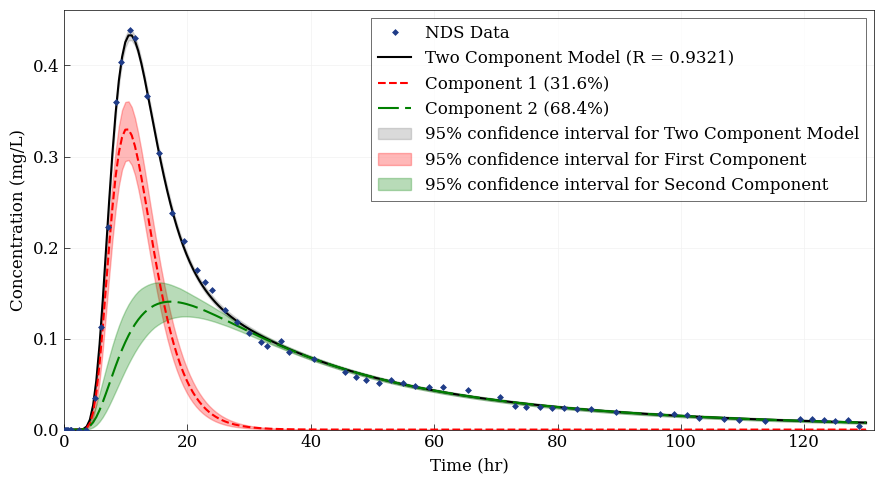

In [40]:
# Journal-style figure (Times New Roman 11 pt; Excel-like 0.25 pt grid/spines, 1 pt curve lines)
_pt = 1.5
_pt_hair = 0.5
font_size = 12
_grid_gray = "#F2F2F2"  # white ~5% toward black (Excel-style major grid)

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "in",
        "ytick.direction": "in",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    h_ci_mix = ax.fill_between(t_plot, lo_mix, hi_mix, color="0.35", alpha=0.22)
    h_line_mix, = ax.plot(t_plot, mean_mix, color="black", linewidth=_pt)

    h_ci_c1 = ax.fill_between(t_plot, lo_1, hi_1, color="red", alpha=0.28)
    h_line_c1, = ax.plot(t_plot, mean_1, color="red", linewidth=_pt, linestyle="--")

    h_ci_c2 = ax.fill_between(t_plot, lo_2, hi_2, color="green", alpha=0.28)
    h_line_c2, = ax.plot(t_plot, mean_2, color="green", linewidth=_pt, linestyle=(0, (10, 3)))

    # markersize=3 ≈ 3 pt marker (Excel-style); edge matches fill color
    h_nds, = ax.plot(
        t_true,
        c_true,
        linestyle="None",
        marker="D",
        markersize=3,
        markerfacecolor="#1f3c88",
        markeredgecolor="#1f3c88",
        markeredgewidth=_pt_hair,
        zorder=5,
    )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("Concentration (mg/L)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    x_hi = max(float(np.max(t_plot)), float(np.max(t_true)))
    y_hi = float(
        np.nanmax(
            [
                hi_mix.max(),
                hi_1.max(),
                hi_2.max(),
                float(np.max(c_true)),
            ]
        )
    )
    ax.set_xlim(0, x_hi * 1.01)
    ax.set_ylim(0, y_hi * 1.05)

    # Mean fr weights across the same elite runs as the curves (requires prep cell with `elite`)
    fr1_mean = float(np.mean(elite["best_fr1"].to_numpy()))
    fr2_mean = float(np.mean(elite["best_fr2"].to_numpy()))
    den = fr1_mean + fr2_mean
    pct1 = 100.0 * fr1_mean / den if den > 0 else 0.0
    pct2 = 100.0 * fr2_mean / den if den > 0 else 0.0
    R_sum = fr1_mean + fr2_mean

    leg_handles = [
        h_nds,
        h_line_mix,
        h_line_c1,
        h_line_c2,
        h_ci_mix,
        h_ci_c1,
        h_ci_c2,
    ]
    leg_labels = [
        "NDS Data",
        f"Two Component Model (R = {R_sum:.4f})",
        f"Component 1 ({pct1:.1f}%)",
        f"Component 2 ({pct2:.1f}%)",
        "95% confidence interval for Two Component Model",
        "95% confidence interval for First Component",
        "95% confidence interval for Second Component",
    ]
    leg = ax.legend(
        leg_handles,
        leg_labels,
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="black",
        fancybox=False,
    )
    leg.get_frame().set_linewidth(_pt_hair)
    leg.get_frame().set_edgecolor("black")

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    # Uncomment to save: no outer figure stroke; tight crop (pad_inches=0)
    fig.savefig(
        "ensemble_mixture_components.pdf",
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight",
        pad_inches=1
    )

    plt.show()


In [41]:
elite

,run_idx,seed,best_MRT1,best_MRT2,best_Pe1,best_Pe2,best_fr1,best_fr2,R,f1,f2,J_m
96,97,197,11.49,49.39,15.31,1.97,0.2613,0.6835,0.9448,0.2766,0.7234,0.0312
754,755,855,11.45,47.76,15.41,2.14,0.2675,0.6637,0.9313,0.2873,0.7127,0.0312
969,970,1070,11.45,48.34,15.38,2.03,0.2633,0.6714,0.9347,0.2817,0.7183,0.0312
1021,1022,1122,11.56,49.50,14.73,2.15,0.2849,0.6541,0.9390,0.3034,0.6966,0.0313
841,842,942,11.55,49.45,15.23,2.02,0.2713,0.6661,0.9375,0.2894,0.7106,0.0314
...,...,...,...,...,...,...,...,...,...,...,...,...
56,57,157,11.59,48.59,14.56,2.46,0.3001,0.6136,0.9138,0.3285,0.6715,0.0353
1001,1002,1102,11.55,45.72,14.26,2.75,0.3050,0.6051,0.9101,0.3351,0.6649,0.0353
459,460,560,11.79,47.43,13.60,2.80,0.3287,0.5764,0.9051,0.3632,0.6368,0.0354
511,512,612,11.97,50.67,12.53,2.69,0.3472,0.5792,0.9263,0.3748,0.6252,0.0355


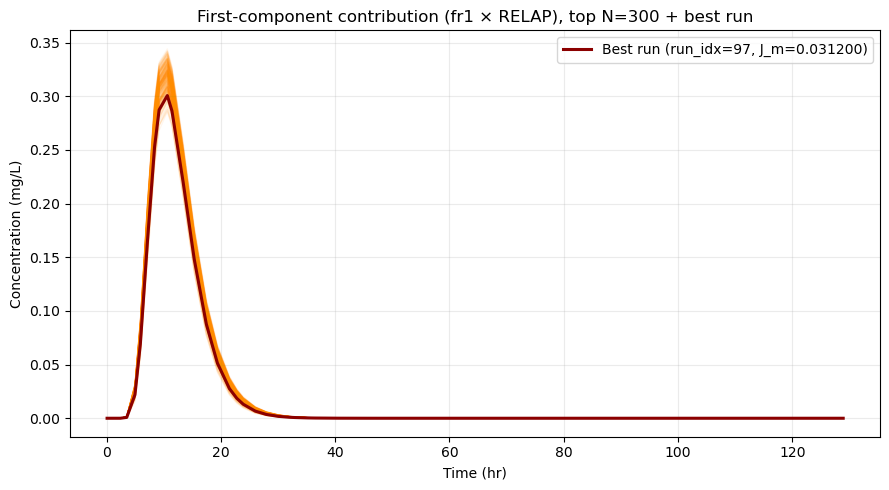

In [25]:
# First-component fr1 * RELAP(t; MRT1, Pe1): all top-N elite runs (§15), then the single best run on top (no mean).
N_best = 300
elite = ensemble.nsmallest(N_best, "J_m")

best_elite = elite.iloc[0]
fig, ax = plt.subplots(figsize=(9, 5))

for _, row in elite.iterrows():
    c1 = row["best_fr1"] * np.asarray(
        modelRELAP(t_true, row["best_MRT1"], row["best_Pe1"]), dtype=float
    )
    ax.plot(t_true, c1, color="darkorange", alpha=0.07, linewidth=0.9)

c1_best = best_elite["best_fr1"] * np.asarray(
    modelRELAP(t_true, best_elite["best_MRT1"], best_elite["best_Pe1"]), dtype=float
)
ax.plot(
    t_true,
    c1_best,
    color="darkred",
    linewidth=2.2,
    label=f"Best run (run_idx={int(best_elite['run_idx'])}, J_m={best_elite['J_m']:.6f})",
)

ax.set_xlabel("Time (hr)")
ax.set_ylabel("Concentration (mg/L)")
ax.set_title(f"First-component contribution (fr1 × RELAP), top N={len(elite)} + best run")
ax.legend(loc="best")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


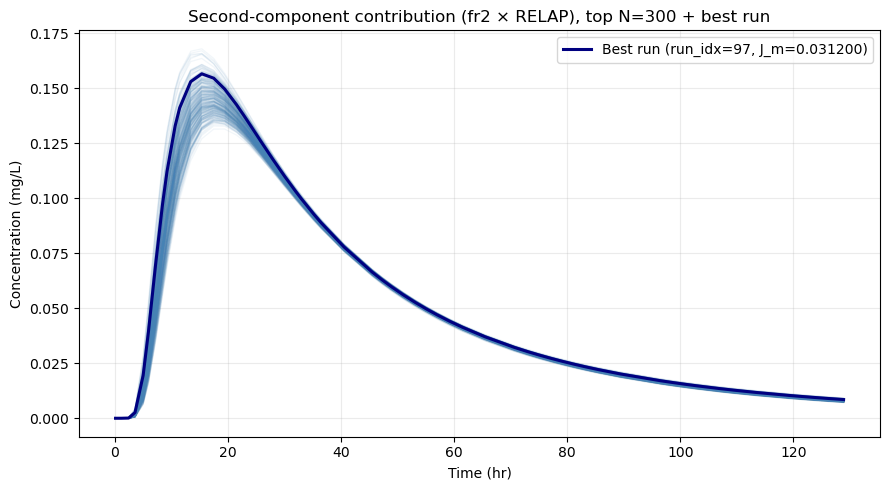

In [26]:
# Second-component fr2 * RELAP(t; MRT2, Pe2): all top-N elite runs (§15), then the single best run on top (no mean).
N_best = 300
elite = ensemble.nsmallest(N_best, "J_m")

best_elite = elite.iloc[0]
fig, ax = plt.subplots(figsize=(9, 5))

for _, row in elite.iterrows():
    c2 = row["best_fr2"] * np.asarray(
        modelRELAP(t_true, row["best_MRT2"], row["best_Pe2"]), dtype=float
    )
    ax.plot(t_true, c2, color="steelblue", alpha=0.07, linewidth=0.9)

c2_best = best_elite["best_fr2"] * np.asarray(
    modelRELAP(t_true, best_elite["best_MRT2"], best_elite["best_Pe2"]), dtype=float
)
ax.plot(
    t_true,
    c2_best,
    color="navy",
    linewidth=2.2,
    label=f"Best run (run_idx={int(best_elite['run_idx'])}, J_m={best_elite['J_m']:.6f})",
)

ax.set_xlabel("Time (hr)")
ax.set_ylabel("Concentration (mg/L)")
ax.set_title(f"Second-component contribution (fr2 × RELAP), top N={len(elite)} + best run")
ax.legend(loc="best")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
